Import packages before performing exploratory data analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('data/raw/shopping.csv')
df.head()


,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


Import and explore the clean data:

In [6]:
df_clean = pd.read_csv('data/processed/shopping_cleaned.csv')

In [7]:
df_clean.head()

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method
0,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,Present,Standard,No,0,Credit Card
1,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,Missing,Standard,No,0,Credit Card
2,26.0,Male,Leggings,23.595139,Nevada,XL,Brown,Winter,Missing,Standard,No,3,Credit Card
3,43.0,Male,Dress,34.079015,California,M,Terra cotta,Fall,Present,Standard,No,0,Credit Card
4,29.0,Male,Shorts,23.796439,Minnesota,M,Lavender,Summer,Present,Express,No,0,Credit Card


In [8]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    3158 non-null   float64
 1   Gender                 3158 non-null   str    
 2   Item Purchased         3158 non-null   str    
 3   Purchase Amount (USD)  3158 non-null   float64
 4   Location               3158 non-null   str    
 5   Size                   3158 non-null   str    
 6   Color                  3158 non-null   str    
 7   Season                 3158 non-null   str    
 8   Review Rating          3158 non-null   str    
 9   Shipping Type          3158 non-null   str    
 10  Promo Code Used        3158 non-null   str    
 11  Previous Purchases     3158 non-null   int64  
 12  Payment Method         3158 non-null   str    
dtypes: float64(2), int64(1), str(10)
memory usage: 320.9 KB


In [9]:
df_clean.describe()

,Age,Purchase Amount (USD),Previous Purchases
count,3158.000000,3158.000000,3158.000000
mean,34.185244,38.812750,5.860988
std,10.578195,11.525595,5.844408
min,18.000000,11.946095,0.000000
25%,26.000000,29.419108,1.000000
50%,33.000000,37.126663,4.000000
75%,41.000000,48.974363,9.000000
max,73.000000,68.327455,20.000000


## What is the age demographic of our customers?

In [10]:
df_clean['Age'].describe()

count    3158.000000
mean       34.185244
std        10.578195
min        18.000000
25%        26.000000
50%        33.000000
75%        41.000000
max        73.000000
Name: Age, dtype: float64

Text(0.5, 1.0, 'Shopper Age Distribution')

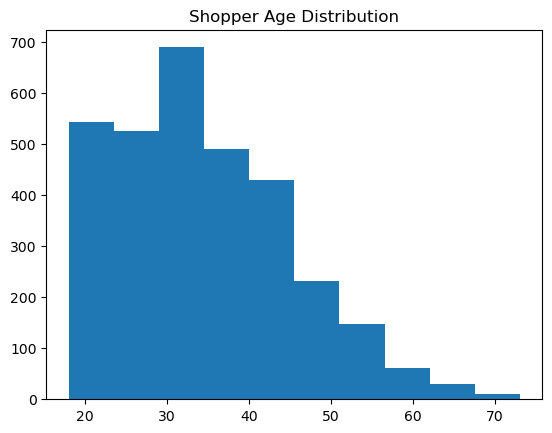

In [58]:
plt.hist(df_clean['Age'])
plt.title("Shopper Age Distribution")

75% of the shoppers are 41 years or younger.

## What item type is the most popular?

In [12]:
purchases = df_clean['Item Purchased'].value_counts()
purchases

Item Purchased
Shorts           259
Sunglasses       258
Running Shoes    248
Dress            228
Handbag          220
T-shirt          212
Backpack         185
Sweater          185
Gloves           180
Leggings         176
Pajamas          176
Socks            172
Hoodie           163
Scarf            157
Jacket           134
Boots            134
Jeans             46
Belt              25
Name: count, dtype: int64

<Axes: ylabel='Item Purchased'>

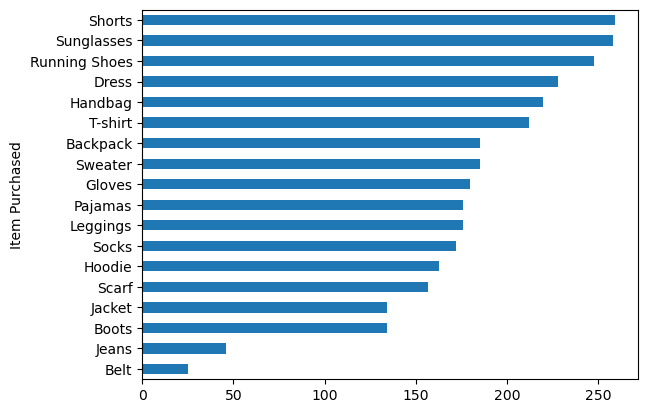

In [13]:
#df_clean['Item Purchased'].value_counts().plot(kind='barh')
df_clean['Item Purchased'].value_counts().sort_values().plot(kind='barh')

The first 6 most sold items are warm weather themed or for all-year use.
A question to further explore could be whether sales are also highest during the warmer years.

## What locations are most of our sales coming from?

In [14]:
locations = df_clean['Location'].value_counts()
locations

Location
California        82
Alabama           73
Montana           73
Illinois          73
Delaware          72
Nebraska          72
Minnesota         71
West Virginia     70
Texas             69
Vermont           69
South Carolina    68
Louisiana         68
Nevada            67
New Mexico        67
Maryland          67
North Carolina    67
Utah              66
Idaho             66
North Dakota      65
Wisconsin         65
Georgia           65
Kentucky          64
Mississippi       64
Missouri          64
Massachusetts     63
Indiana           63
Maine             63
Virginia          62
New Hampshire     62
Connecticut       62
Ohio              62
New York          62
Oregon            61
Pennsylvania      61
Arkansas          61
Michigan          60
Tennessee         60
Colorado          59
Iowa              59
Oklahoma          59
Washington        57
South Dakota      56
Florida           55
Alaska            54
New Jersey        54
Wyoming           53
Rhode Island      53
Kans

<Axes: ylabel='Location'>

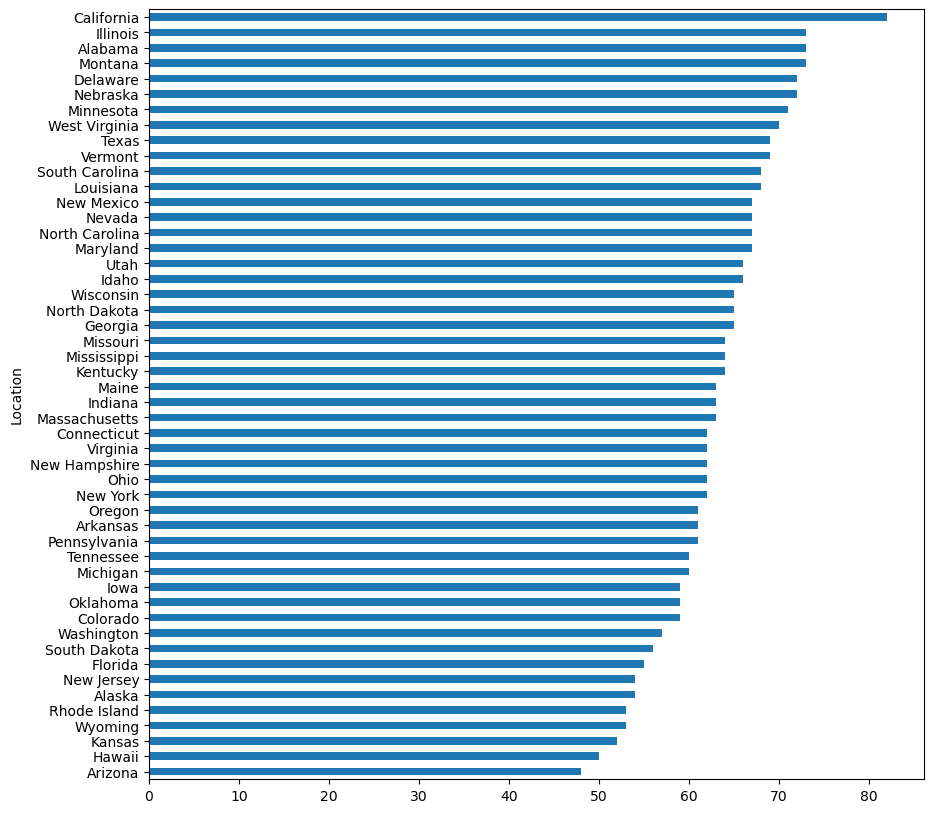

In [15]:
plt.figure(figsize=(10, 10))
df_clean['Location'].value_counts().sort_values().plot(kind='barh')

There is no one state that has a disproportional amount of sales compared to others, however the state with the least purchase activity, Arizona, is two thirds of the purchases of the most active state, California.

## Which states generate the most revenue on average?

In [16]:
location_rev = df_clean.groupby('Location')['Purchase Amount (USD)'].mean()
location_rev.sort_values()

Location
Kansas            34.754332
Alaska            35.128052
Connecticut       35.668796
Arizona           36.207463
Alabama           36.317989
Colorado          37.416237
Vermont           37.477666
South Dakota      37.506164
Illinois          37.575548
Georgia           37.661528
Virginia          37.721602
Minnesota         37.809030
Kentucky          37.988451
California        37.996401
Oklahoma          38.097884
Rhode Island      38.214919
Pennsylvania      38.250639
Tennessee         38.253269
Montana           38.290344
Michigan          38.461408
North Dakota      38.482397
Texas             38.494826
Wyoming           38.522256
New Jersey        38.670895
Ohio              38.716308
Delaware          38.923192
Maine             38.944262
Washington        38.952245
Utah              38.990109
New Hampshire     39.055198
New Mexico        39.193420
Maryland          39.201186
North Carolina    39.213291
Wisconsin         39.234511
Louisiana         39.297439
Mississippi

In [17]:
location_rev.describe()

count    50.000000
mean     38.799692
std       1.682119
min      34.754332
25%      37.990439
50%      38.819750
75%      39.397643
max      44.015818
Name: Purchase Amount (USD), dtype: float64

<Axes: ylabel='Location'>

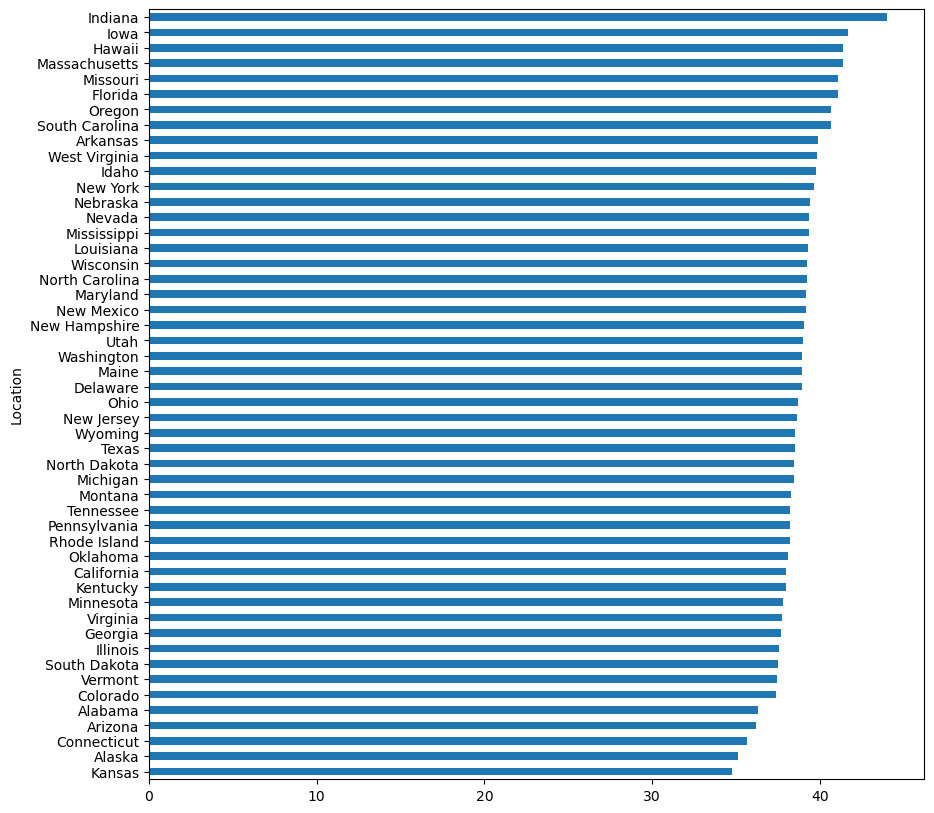

In [18]:
plt.figure(figsize=(10, 10))
location_rev.sort_values().plot(kind='barh')

Average spending per state ranges from $34-$44, customers in Indiana spending on average ~$10 more than in Kansas.

## What are the most popular colors by season?

In [19]:
season_colors = df_clean.groupby('Season')['Color'].max()
season_colors

Season
Fall      White
Spring    White
Summer    White
Winter    White
Name: Color, dtype: str

White is the most popular color across all 4 seasons

##  What is the most popular clothing item by season?

In [20]:
season_clothing = df_clean.groupby('Season')['Item Purchased'].max()
season_clothing

Season
Fall      T-shirt
Spring    T-shirt
Summer    T-shirt
Winter    Sweater
Name: Item Purchased, dtype: str

A T-shirt is the most popular item purchased across seasons, except for winter.

## What is the effect of promo codes on the dollar amount of purchases?

In [21]:
pd.pivot_table(df_clean, values='Purchase Amount (USD)', index='Promo Code Used')

,Purchase Amount (USD)
Promo Code Used,
No,30.155751
Yes,50.067480


When a promo code is used, the average dollar amount per purchase is 40% higher than without one.

## When do users leave a review?

In [22]:
df_clean['Review Present'] = df_clean['Review Rating'].str.contains('Present', na=False)
df_clean

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Review Present
0,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,Present,Standard,No,0,Credit Card,True
1,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,Missing,Standard,No,0,Credit Card,False
2,26.0,Male,Leggings,23.595139,Nevada,XL,Brown,Winter,Missing,Standard,No,3,Credit Card,False
3,43.0,Male,Dress,34.079015,California,M,Terra cotta,Fall,Present,Standard,No,0,Credit Card,True
4,29.0,Male,Shorts,23.796439,Minnesota,M,Lavender,Summer,Present,Express,No,0,Credit Card,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3153,39.0,Male,Running Shoes,55.636680,Kansas,L,White,Summer,Missing,2-Day Shipping,Yes,11,Venmo,False
3154,43.0,Female,Sunglasses,61.610602,Colorado,S,Burnt orange,Fall,Missing,2-Day Shipping,Yes,7,Venmo,False
3155,37.0,Male,Pajamas,44.600556,Alaska,S,Aubergine,Winter,Present,2-Day Shipping,Yes,20,Venmo,True
3156,39.0,Male,Hoodie,45.343778,Illinois,S,Brick red,Fall,Missing,2-Day Shipping,Yes,3,Venmo,False


In [24]:
gender_versus_reviews = pd.pivot_table(df_clean[['Gender', 'Review Present']], index='Gender', aggfunc={"Review Present": ["mean", "count"]})
gender_versus_reviews

Review Present          
                    count      mean
Gender                             
Female               1550  0.365806
Male                 1579  0.351488
Non-binary             29  0.551724

Non-binary customers left more reviews on average, however were a small subset of the customer base (less than 1%).

In [25]:
item_vs_review = pd.pivot_table(df_clean[['Item Purchased', 'Review Present']], index='Item Purchased', aggfunc={"Review Present": ["mean", "count"]})
item_vs_review


Review Present          
                        count      mean
Item Purchased                         
Backpack                  185  0.394595
Belt                       25  0.480000
Boots                     134  0.343284
Dress                     228  0.390351
Gloves                    180  0.316667
Handbag                   220  0.345455
Hoodie                    163  0.349693
Jacket                    134  0.358209
Jeans                      46  0.282609
Leggings                  176  0.369318
Pajamas                   176  0.403409
Running Shoes             248  0.362903
Scarf                     157  0.394904
Shorts                    259  0.285714
Socks                     172  0.395349
Sunglasses                258  0.352713
Sweater                   185  0.340541
T-shirt                   212  0.391509

In [60]:
item_count_series.describe()

count    18.000000
mean      0.364290
std       0.046046
min       0.282609
25%       0.343826
50%       0.360556
75%       0.393823
max       0.480000
Name: (Review Present, mean), dtype: float64

Text(0.5, 1.0, 'Percent of Reviews Left Per Item')

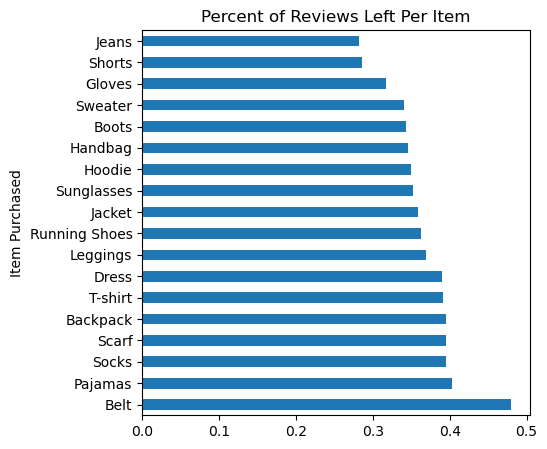

In [51]:

plt.figure(figsize=(5, 5))
item_count_series = item_vs_review['Review Present', 'mean']
item_count_series
item_count_series.sort_values(ascending=False).plot(kind='barh')
plt.title('Percent of Reviews Left Per Item')


Jeans and shorts have some of the lowest reviews per purchase. Belts had the highest average reviews left, but were the least bought.

In [26]:
location_versus_review = pd.pivot_table(df_clean[['Location', 'Review Present']], index='Location', aggfunc={"Review Present": ["mean", "count"]})
location_versus_review

Review Present          
                        count      mean
Location                               
Alabama                    73  0.356164
Alaska                     54  0.500000
Arizona                    48  0.270833
Arkansas                   61  0.426230
California                 82  0.463415
Colorado                   59  0.254237
Connecticut                62  0.322581
Delaware                   72  0.402778
Florida                    55  0.381818
Georgia                    65  0.353846
Hawaii                     50  0.340000
Idaho                      66  0.439394
Illinois                   73  0.410959
Indiana                    63  0.317460
Iowa                       59  0.372881
Kansas                     52  0.346154
Kentucky                   64  0.312500
Louisiana                  68  0.485294
Maine                      63  0.476190
Maryland                   67  0.432836
Massachusetts              63  0.317460
Michigan                   60  0.300000
Minnesota                  71  0.281690
Mississippi                64  0.343750
Missouri                   64  0.375000
Montana                    73  0.356164
Nebraska                   72  0.458333
Nevada                     67  0.238806
New Hampshire              62  0.306452
New Jersey                 54  0.203704
New Mexico                 67  0.298507
New York                   62  0.322581
North Carolina             67  0.447761
North Dakota               65  0.276923
Ohio                       62  0.387097
Oklahoma                   59  0.338983
Oregon                     61  0.344262
Pennsylvania               61  0.295082
Rhode Island               53  0.415094
South Carolina             68  0.308824
South Dakota               56  0.285714
Tennessee                  60  0.466667
Texas                      69  0.362319
Utah                       66  0.469697
Vermont                    69  0.318841
Virginia                   62  0.467742
Washington                 57  0.315789
West Virginia              70  0.300000
Wisconsin                  65  0.400000
Wyoming                    53  0.245283

In [27]:
location_versus_review.describe()

Review Present           
               count       mean
count      50.000000  50.000000
mean       63.160000   0.358282
std         6.795437   0.073260
min        48.000000   0.203704
25%        59.250000   0.307045
50%        63.000000   0.345208
75%        67.000000   0.414060
max        82.000000   0.500000

Reviews left per state vary widely - with a 30% difference between the lowest and highest.

In [ ]:
season_versus_review = pd.pivot_table(df_clean[['Season', 'Review Present']], index='Season', aggfunc={"Review Present": ["mean", "count"]})
season_versus_review

Review Present          
                count      mean
Season                         
Fall              872  0.350917
Spring            477  0.354298
Summer            765  0.359477
Winter           1044  0.371648

Average number of reviews left is similar across seasons.

In [31]:
shipping_type_versus_review = pd.pivot_table(df_clean[['Shipping Type', 'Review Present']], index='Shipping Type', aggfunc={"Review Present": ["mean", "count"]})
shipping_type_versus_review

Review Present          
                        count      mean
Shipping Type                          
2-Day Shipping            953  0.354669
Express                   225  0.368889
Next Day Air              223  0.313901
Standard                 1756  0.368451
Store Pickup                1  0.000000

Next Day Air shipping has on average 5% fewer reviews left compared to other modes of shipping.

In [53]:
promo_code_versus_review = pd.pivot_table(df_clean[['Promo Code Used', 'Review Present']], index='Promo Code Used', aggfunc={"Review Present": ["mean", "count"]})
promo_code_versus_review

Review Present          
                         count      mean
Promo Code Used                         
No                        1785  0.367507
Yes                       1373  0.351056

Whether a promo code was used or not has not shown a noticeable effect on percent of purchases leading to a review left.

In [57]:
payment_method_versus_review = pd.pivot_table(df_clean[['Payment Method', 'Review Present']], index='Payment Method', aggfunc={"Review Present": ["mean", "count"]})
payment_method_versus_review

Review Present          
                        count      mean
Payment Method                         
Bank Transfer              10  0.200000
Cash                        9  0.333333
Credit Card              1139  0.376646
Debit Card               1043  0.358581
PayPal                    496  0.346774
Venmo                     461  0.342733

Reviews are left similarly in frequency across payment methods except bank transfers. However they were the method of payment only 10 times.

# Exploratory Analysis Findings
Promo codes have a 40% increase effect on customer spending. Customers from different states also left reviews at different rates, up to a 30% difference.